In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

val_df = pd.read_csv(
    "../data/processed/validation_processed.csv"
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (68976, 3)
Validation: (8878, 3)


In [3]:
X_train = train_df["clean_text"]
y_train = train_df["labels"]

X_val = val_df["clean_text"]
y_val = val_df["labels"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (68976,)
y_train: (68976,)
X_val: (8878,)
y_val: (8878,)


In [4]:
tfidf_vectorizer = joblib.load(
    "../models/tfidf_vectorizer.joblib"
)

print("TF-IDF vectorizer loaded!")

TF-IDF vectorizer loaded!


In [5]:
X_train_tfidf = tfidf_vectorizer.transform(
    X_train
)

X_val_tfidf = tfidf_vectorizer.transform(
    X_val
)

print(
    "Train TF-IDF:",
    X_train_tfidf.shape
)

print(
    "Validation TF-IDF:",
    X_val_tfidf.shape
)

Train TF-IDF: (68976, 100000)
Validation TF-IDF: (8878, 100000)


In [6]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

In [7]:
svm_model.fit(
    X_train_tfidf,
    y_train
)

print("Training completed!")

Training completed!


In [9]:
y_val_pred = svm_model.predict(
    X_val_tfidf
)
comparison = pd.DataFrame({
    "Actual": y_val.iloc[:10].values,
    "Predicted": y_val_pred[:10]
})

comparison

,Actual,Predicted
0,nl,nl
1,nl,nl
2,es,es
3,it,it
4,ar,ar
5,ru,ru
6,tr,tr
7,nl,nl
8,fr,fr
9,es,es


In [10]:
accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9954
Accuracy: 99.54%


In [12]:
precision_macro = precision_score(
    y_val,
    y_val_pred,
    average="macro"
)

recall_macro = recall_score(
    y_val,
    y_val_pred,
    average="macro"
)

f1_macro = f1_score(
    y_val,
    y_val_pred,
    average="macro"
)

precision_weighted = precision_score(
    y_val,
    y_val_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_val,
    y_val_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_val,
    y_val_pred,
    average="weighted"
)
print("=== Linear SVM ===")

print(f"Accuracy:           {accuracy:.4f}")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1-score:     {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1-score:  {f1_weighted:.4f}")

=== Linear SVM ===
Accuracy:           0.9954
Macro Precision:    0.9954
Macro Recall:       0.9950
Macro F1-score:     0.9951
Weighted Precision: 0.9955
Weighted Recall:    0.9954
Weighted F1-score:  0.9954


In [13]:
print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

          ar     1.0000    0.9975    0.9988       402
          bg     1.0000    1.0000    1.0000       402
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       402
          en     0.9920    1.0000    0.9960       499
          es     1.0000    1.0000    1.0000       500
          fr     0.9980    1.0000    0.9990       497
          hi     1.0000    0.9428    0.9706       402
          it     0.9979    0.9979    0.9979       468
          ja     1.0000    1.0000    1.0000       500
          nl     0.9830    1.0000    0.9914       463
          pl     0.9978    0.9978    0.9978       463
          pt     1.0000    0.9979    0.9989       469
          ru     1.0000    1.0000    1.0000       402
          sw     0.9481    1.0000    0.9734       402
          th     1.0000    1.0000    1.0000       402
          tr     0.9901    1.0000    0.9950       402
          ur     1.0000    

In [14]:
report = classification_report(
    y_val,
    y_val_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df

,precision,recall,f1-score,support
ar,1.000000,0.997512,0.998755,402.000000
bg,1.000000,1.000000,1.000000,402.000000
de,1.000000,1.000000,1.000000,500.000000
el,1.000000,1.000000,1.000000,402.000000
en,0.992048,1.000000,0.996008,499.000000
es,1.000000,1.000000,1.000000,500.000000
fr,0.997992,1.000000,0.998995,497.000000
hi,1.000000,0.942786,0.970551,402.000000
it,0.997863,0.997863,0.997863,468.000000
ja,1.000000,1.000000,1.000000,500.000000


In [15]:
language_report = report_df.loc[
    sorted(y_val.unique())
]

language_report.sort_values(
    by="f1-score"
).head(10)

,precision,recall,f1-score,support
hi,1.000000,0.942786,0.970551,402.0
sw,0.948113,1.000000,0.973366,402.0
ur,1.000000,0.967662,0.983565,402.0
nl,0.983015,1.000000,0.991435,463.0
tr,0.990148,1.000000,0.995050,402.0
en,0.992048,1.000000,0.996008,499.0
pl,0.997840,0.997840,0.997840,463.0
it,0.997863,0.997863,0.997863,468.0
ar,1.000000,0.997512,0.998755,402.0
pt,1.000000,0.997868,0.998933,469.0


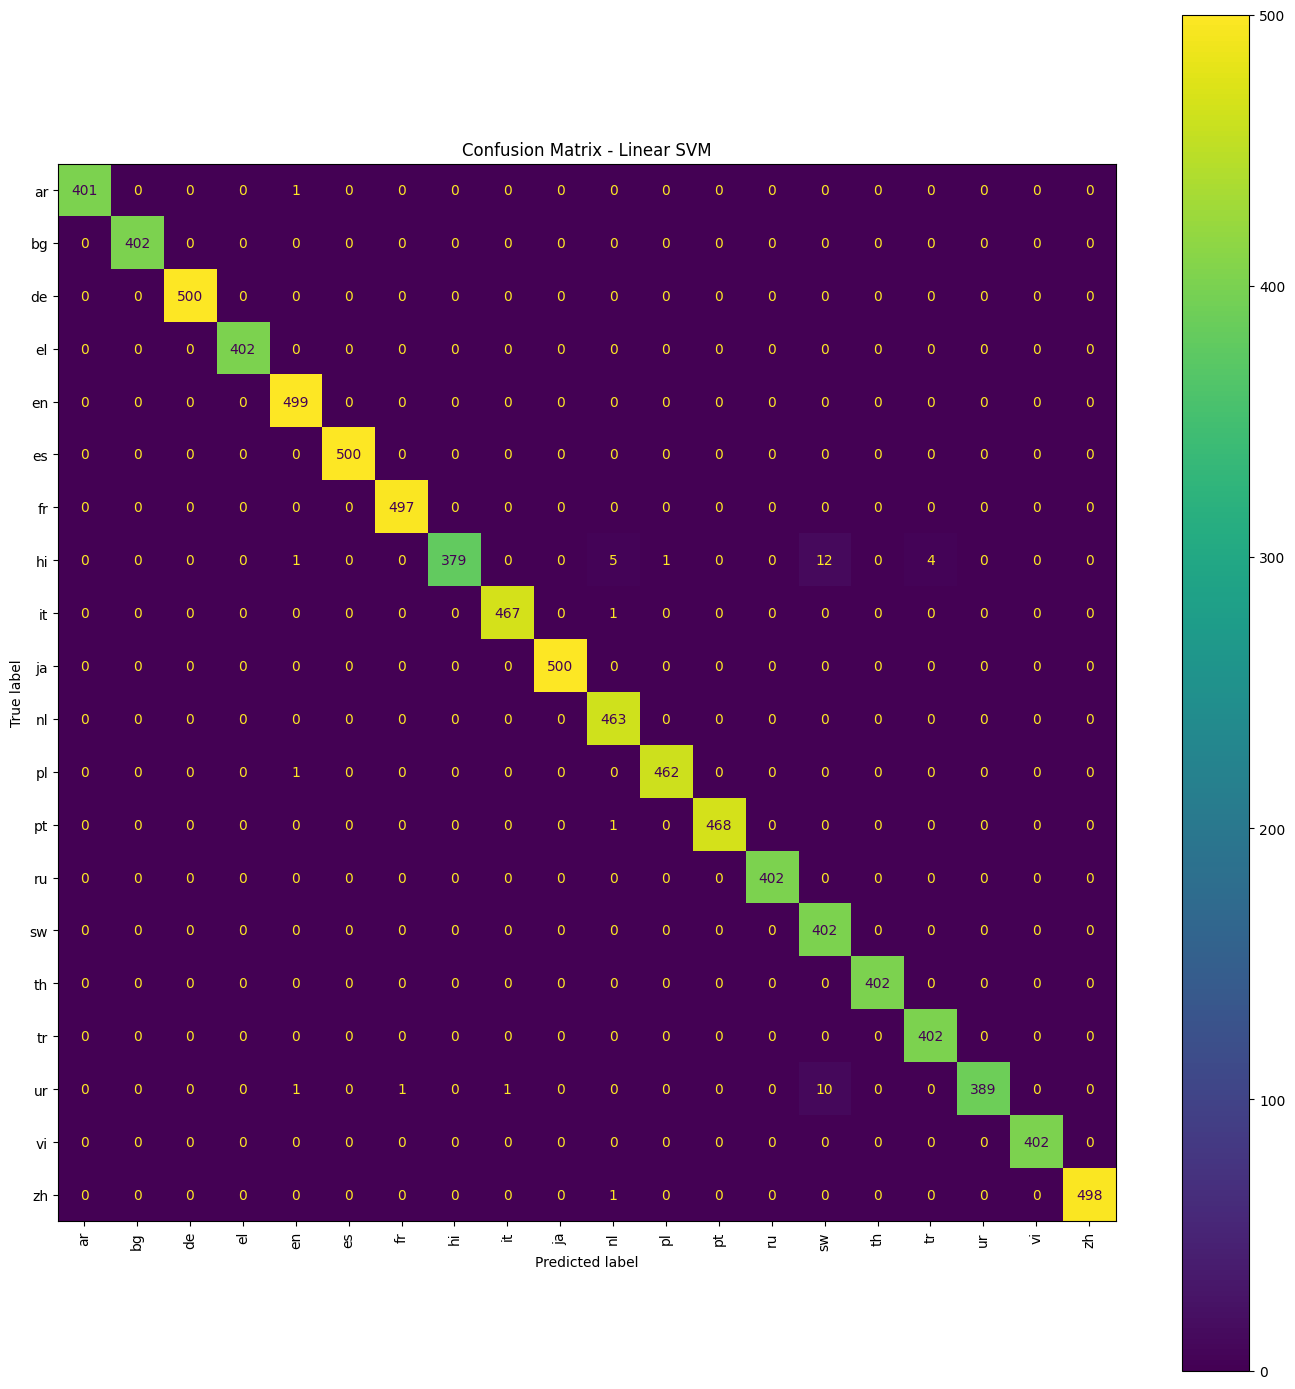

In [16]:
labels = sorted(y_val.unique())

fig, ax = plt.subplots(
    figsize=(14, 14)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    labels=labels,
    display_labels=labels,
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - Linear SVM"
)

plt.tight_layout()
plt.show()

In [17]:
wrong_predictions = val_df.copy()

wrong_predictions["predicted"] = y_val_pred

wrong_predictions = wrong_predictions[
    wrong_predictions["labels"]
    != wrong_predictions["predicted"]
]

print(
    "Số mẫu dự đoán sai:",
    len(wrong_predictions)
)

wrong_predictions[
    [
        "labels",
        "predicted",
        "clean_text"
    ]
].head(20)

Số mẫu dự đoán sai: 41


,labels,predicted,clean_text
119,ar,en,Umeda marks the northern end of the business a...
517,ur,fr,State ko techinal functions outsource karne ka...
720,pt,nl,A actriz 'Desperate Housewives' Kathryn Jooste...
760,hi,pl,nahi. Blood ne uske telescope ko band kar diya.
1029,hi,nl,Maennerchor Society star par varshik nidhi ke ...
1201,hi,sw,hastakshep kee kisee ek pranaalee ke liye yah ...
2308,hi,sw,John Burke (Alabama) anya samakaaleen khaaton ...
2644,pl,en,Sly Stallone's Sone Sage Found Dead in LA
3258,ur,sw,"akhi jumla, Hum samajhte hain kai tum ne ye ma..."
3611,hi,sw,sabhya aur samvedansheel cheez yeh hai ki rash...


In [18]:
correct = (
    y_val.values == y_val_pred
).sum()

incorrect = (
    y_val.values != y_val_pred
).sum()

print("Correct:", correct)
print("Incorrect:", incorrect)
print("Total:", len(y_val))

print(
    "Accuracy check:",
    correct / len(y_val)
)

Correct: 8837
Incorrect: 41
Total: 8878
Accuracy check: 0.9953818427573777


In [19]:
os.makedirs(
    "../outputs/results",
    exist_ok=True
)

svm_results = pd.DataFrame({
    "model": [
        "Linear SVM"
    ],
    "accuracy": [
        accuracy
    ],
    "precision_macro": [
        precision_macro
    ],
    "recall_macro": [
        recall_macro
    ],
    "f1_macro": [
        f1_macro
    ],
    "precision_weighted": [
        precision_weighted
    ],
    "recall_weighted": [
        recall_weighted
    ],
    "f1_weighted": [
        f1_weighted
    ]
})

svm_results

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Linear SVM,0.995382,0.995351,0.994976,0.995068,0.995534,0.995382,0.99537


In [20]:
svm_results.to_csv(
    "../outputs/results/experiment_3_linear_svm.csv",
    index=False
)

print("Experiment 3 results saved!")

Experiment 3 results saved!


In [21]:
joblib.dump(
    svm_model,
    "../models/linear_svm_model.joblib"
)

print("Linear SVM model saved!")

Linear SVM model saved!


In [22]:
loaded_svm_model = joblib.load(
    "../models/linear_svm_model.joblib"
)

print("Model loaded!")

Model loaded!


In [23]:
sample_text = [
    "Bonjour, comment allez-vous?"
]

sample_vector = tfidf_vectorizer.transform(
    sample_text
)

prediction = loaded_svm_model.predict(
    sample_vector
)

print(
    "Predicted language:",
    prediction[0]
)

Predicted language: fr


In [24]:
samples = [
    "Hello, how are you today?",
    "Bonjour, comment allez-vous?",
    "Xin chào, hôm nay bạn khỏe không?",
    "¿Cómo estás hoy?",
    "これは日本語の文章です。",
    "这是一个中文句子。"
]

sample_vectors = tfidf_vectorizer.transform(
    samples
)

predictions = loaded_svm_model.predict(
    sample_vectors
)

for text, language in zip(
    samples,
    predictions
):
    print(
        f"{language:>3} | {text}"
    )

 en | Hello, how are you today?
 fr | Bonjour, comment allez-vous?
 vi | Xin chào, hôm nay bạn khỏe không?
 es | ¿Cómo estás hoy?
 ja | これは日本語の文章です。
 zh | 这是一个中文句子。


## Kết luận

- Linear SVM được sử dụng làm mô hình thử nghiệm thứ ba cho bài toán nhận diện ngôn ngữ văn bản.
- Mô hình sử dụng cùng bộ đặc trưng TF-IDF kết hợp Character N-gram với hai thử nghiệm trước nhằm đảm bảo tính công bằng trong quá trình so sánh.
- Mô hình được huấn luyện trên tập train và đánh giá trên tập validation.
- Các chỉ số Accuracy, Precision, Recall và F1-score được sử dụng để đánh giá hiệu suất của mô hình.
- Classification Report và Confusion Matrix được sử dụng để phân tích khả năng nhận diện đối với từng ngôn ngữ.
- Các trường hợp dự đoán sai được kiểm tra nhằm xác định những dạng văn bản và nhóm ngôn ngữ mà mô hình còn gặp khó khăn.
- Kết quả của Linear SVM được lưu lại để so sánh với Multinomial Naive Bayes và Logistic Regression.
- Tập test vẫn chưa được sử dụng và chỉ được dùng sau khi lựa chọn mô hình tốt nhất dựa trên kết quả validation.